In [1]:
"https://drive.google.com/file/d/1GrwstpJ0H7AwLDPtE6o3aVAKvDtNkZMW/view?usp=sharing"
file_id="1GrwstpJ0H7AwLDPtE6o3aVAKvDtNkZMW"
url=f"https://drive.google.com/uc?id={file_id}"
import pandas as pd
df=pd.read_csv(url)
df

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [2]:
df.isnull().sum()

,0
ID,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


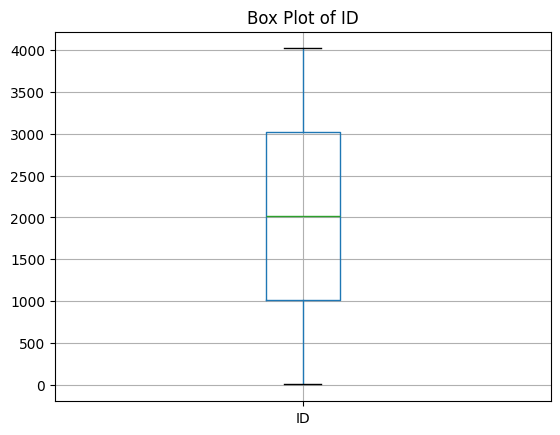

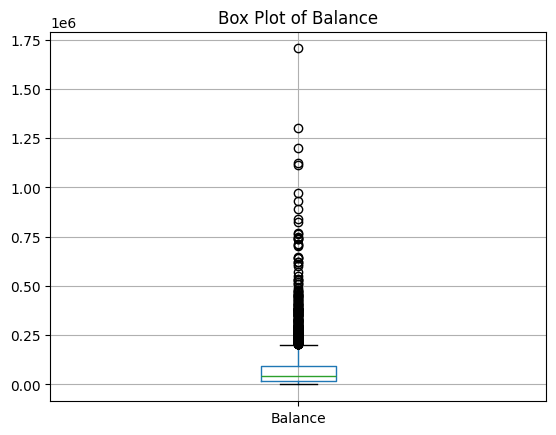

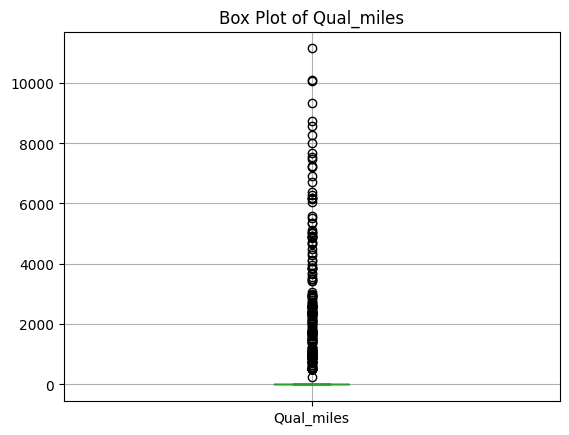

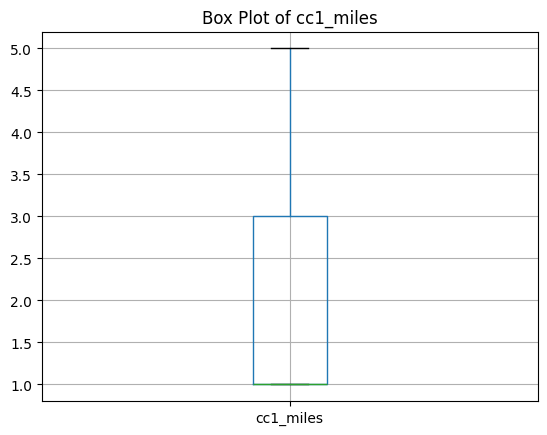

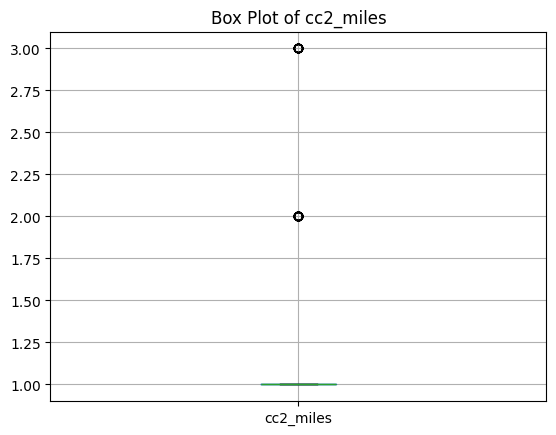

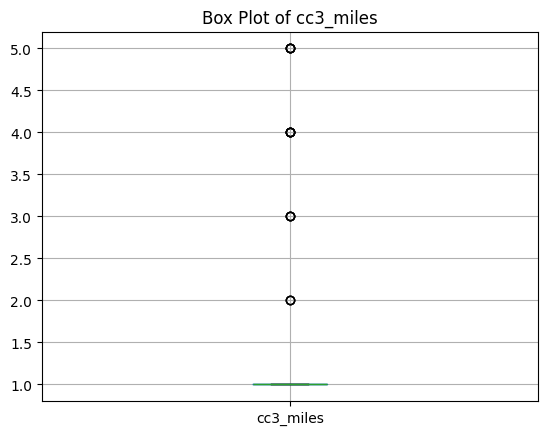

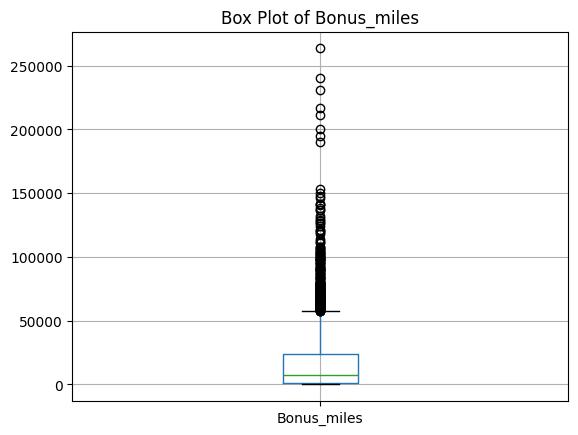

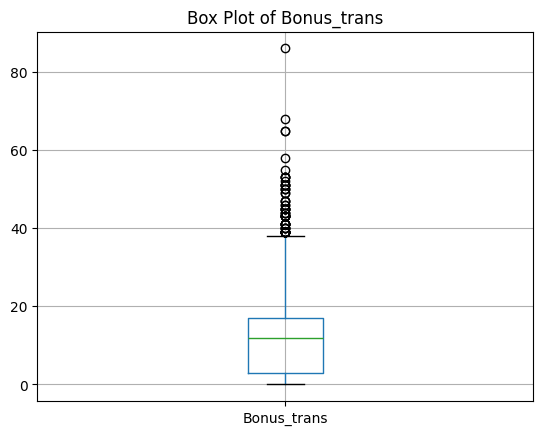

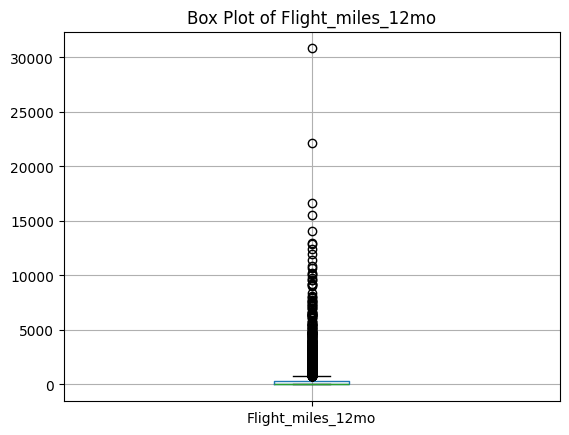

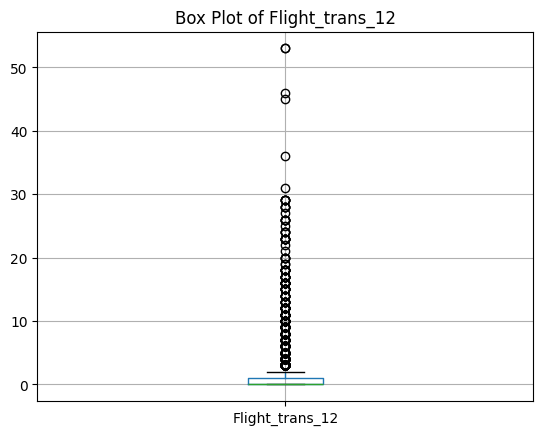

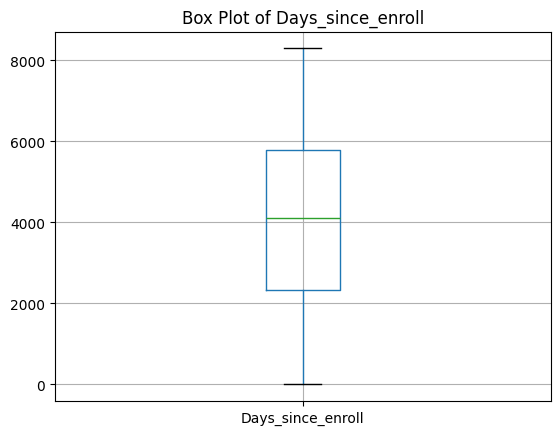

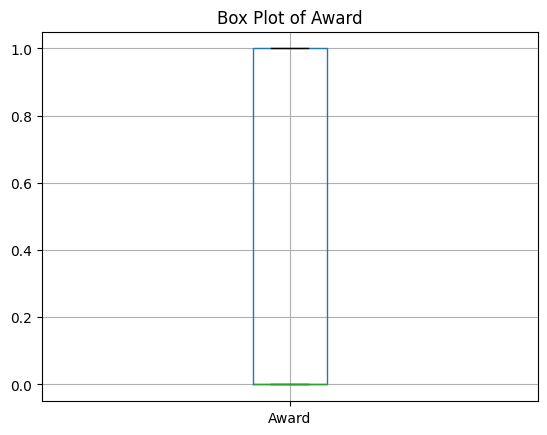

In [3]:
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number').columns:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Box Plot of {col}")
    plt.show()

In [4]:
import numpy as np
skewed_cols = ['Flight_miles_12mo', 'Bonus_miles', 'Bonus_trans']

for col in skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

In [5]:
def cap_iqr(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return s.clip(lower, upper)

for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = cap_iqr(df[col])

In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(df)

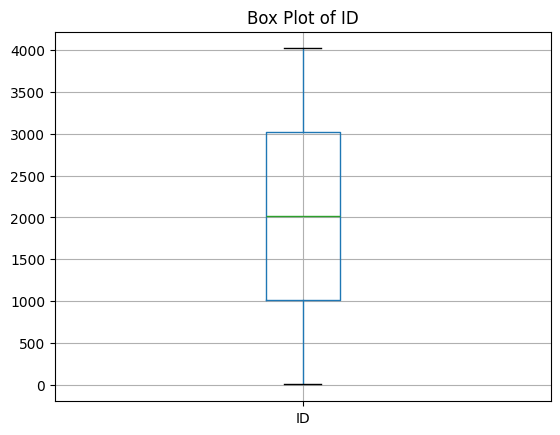

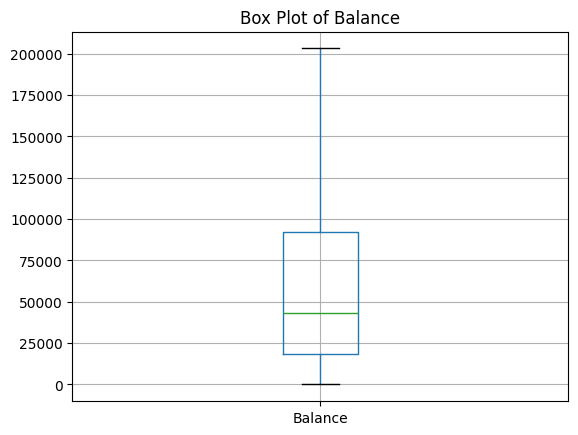

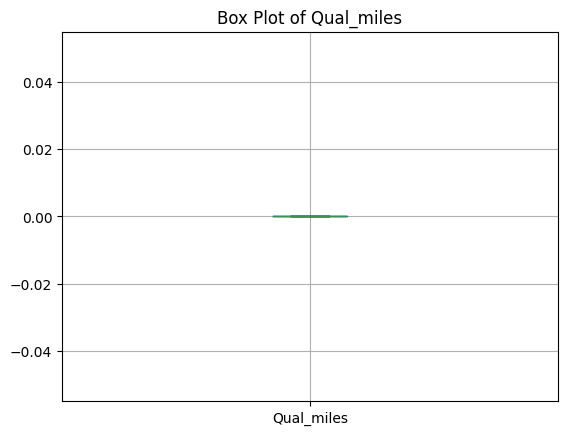

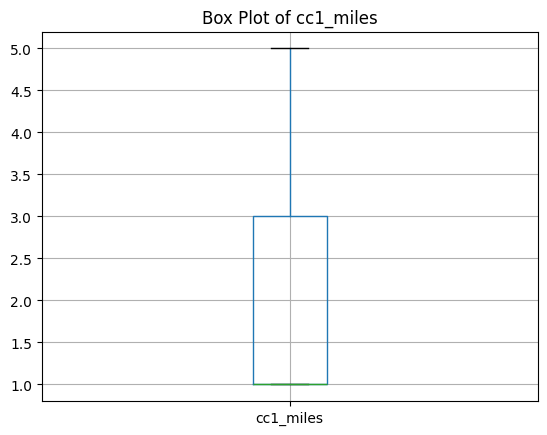

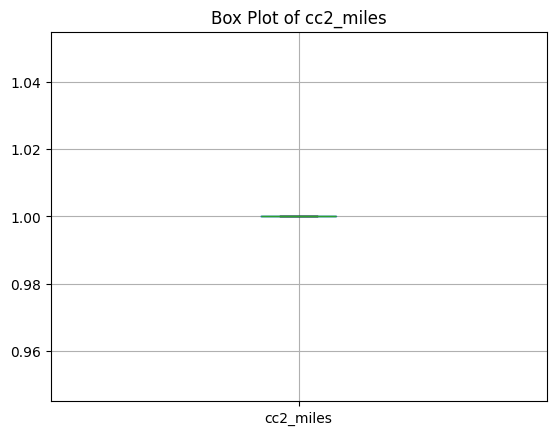

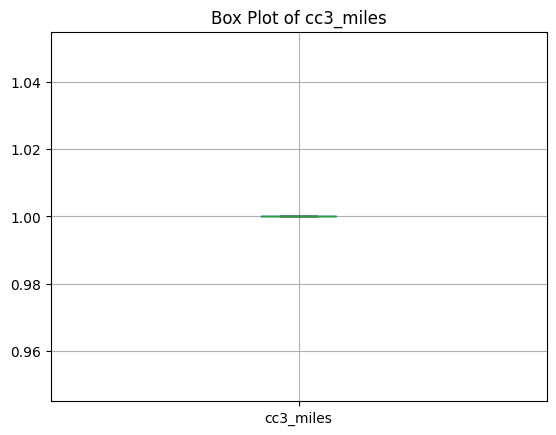

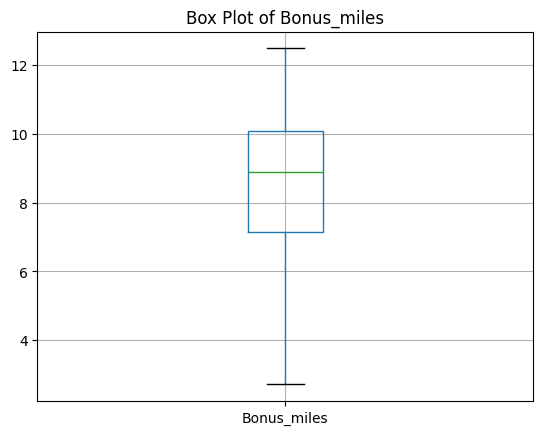

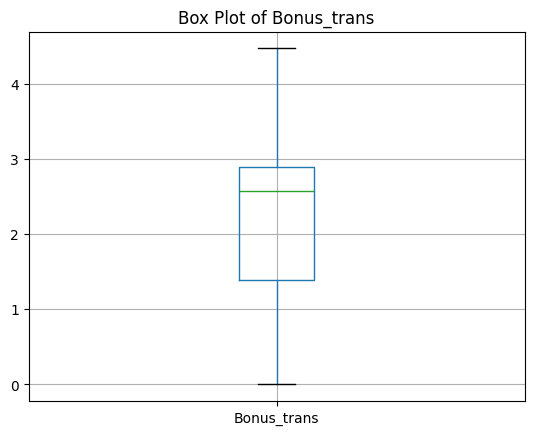

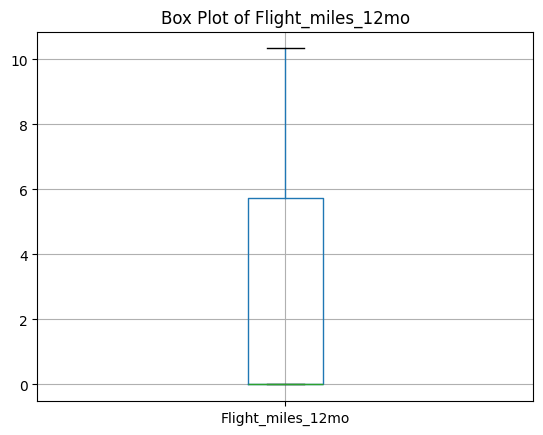

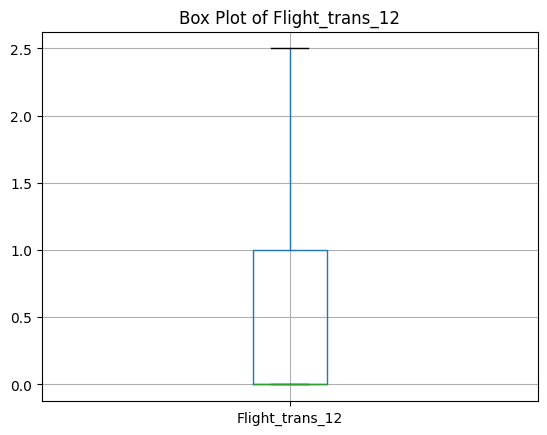

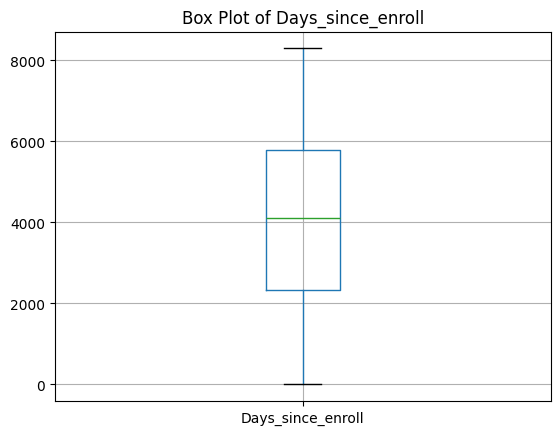

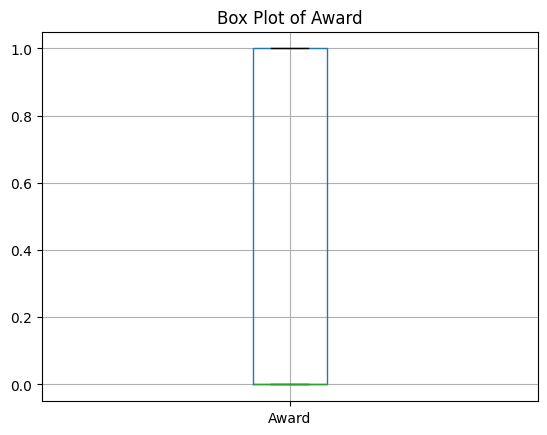

In [7]:
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number').columns:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Box Plot of {col}")
    plt.show()

In [8]:
df.describe()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
count,3999.000000,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,63768.635784,0.0,2.059515,1.0,1.0,8.206455,2.121283,2.103834,0.591523,4118.55939,0.370343
std,1160.764358,58673.700736,0.0,1.376919,0.0,0.0,2.535241,1.057552,3.144648,0.944826,2065.13454,0.482957
min,1.000000,0.000000,0.0,1.000000,1.0,1.0,2.712991,0.000000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,18527.500000,0.0,1.000000,1.0,1.0,7.131699,1.386294,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,43097.000000,0.0,1.000000,1.0,1.0,8.877940,2.564949,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,92404.000000,0.0,3.000000,1.0,1.0,10.077504,2.890372,5.742875,1.000000,5790.50000,1.000000
max,4021.000000,203218.750000,0.0,5.000000,1.0,1.0,12.482514,4.465908,10.335854,2.500000,8296.00000,1.000000


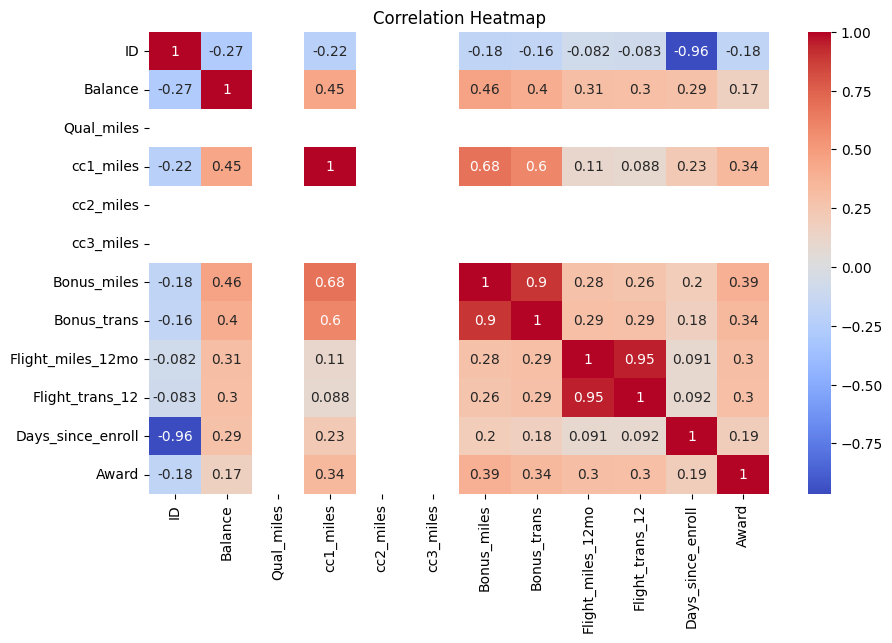

In [9]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

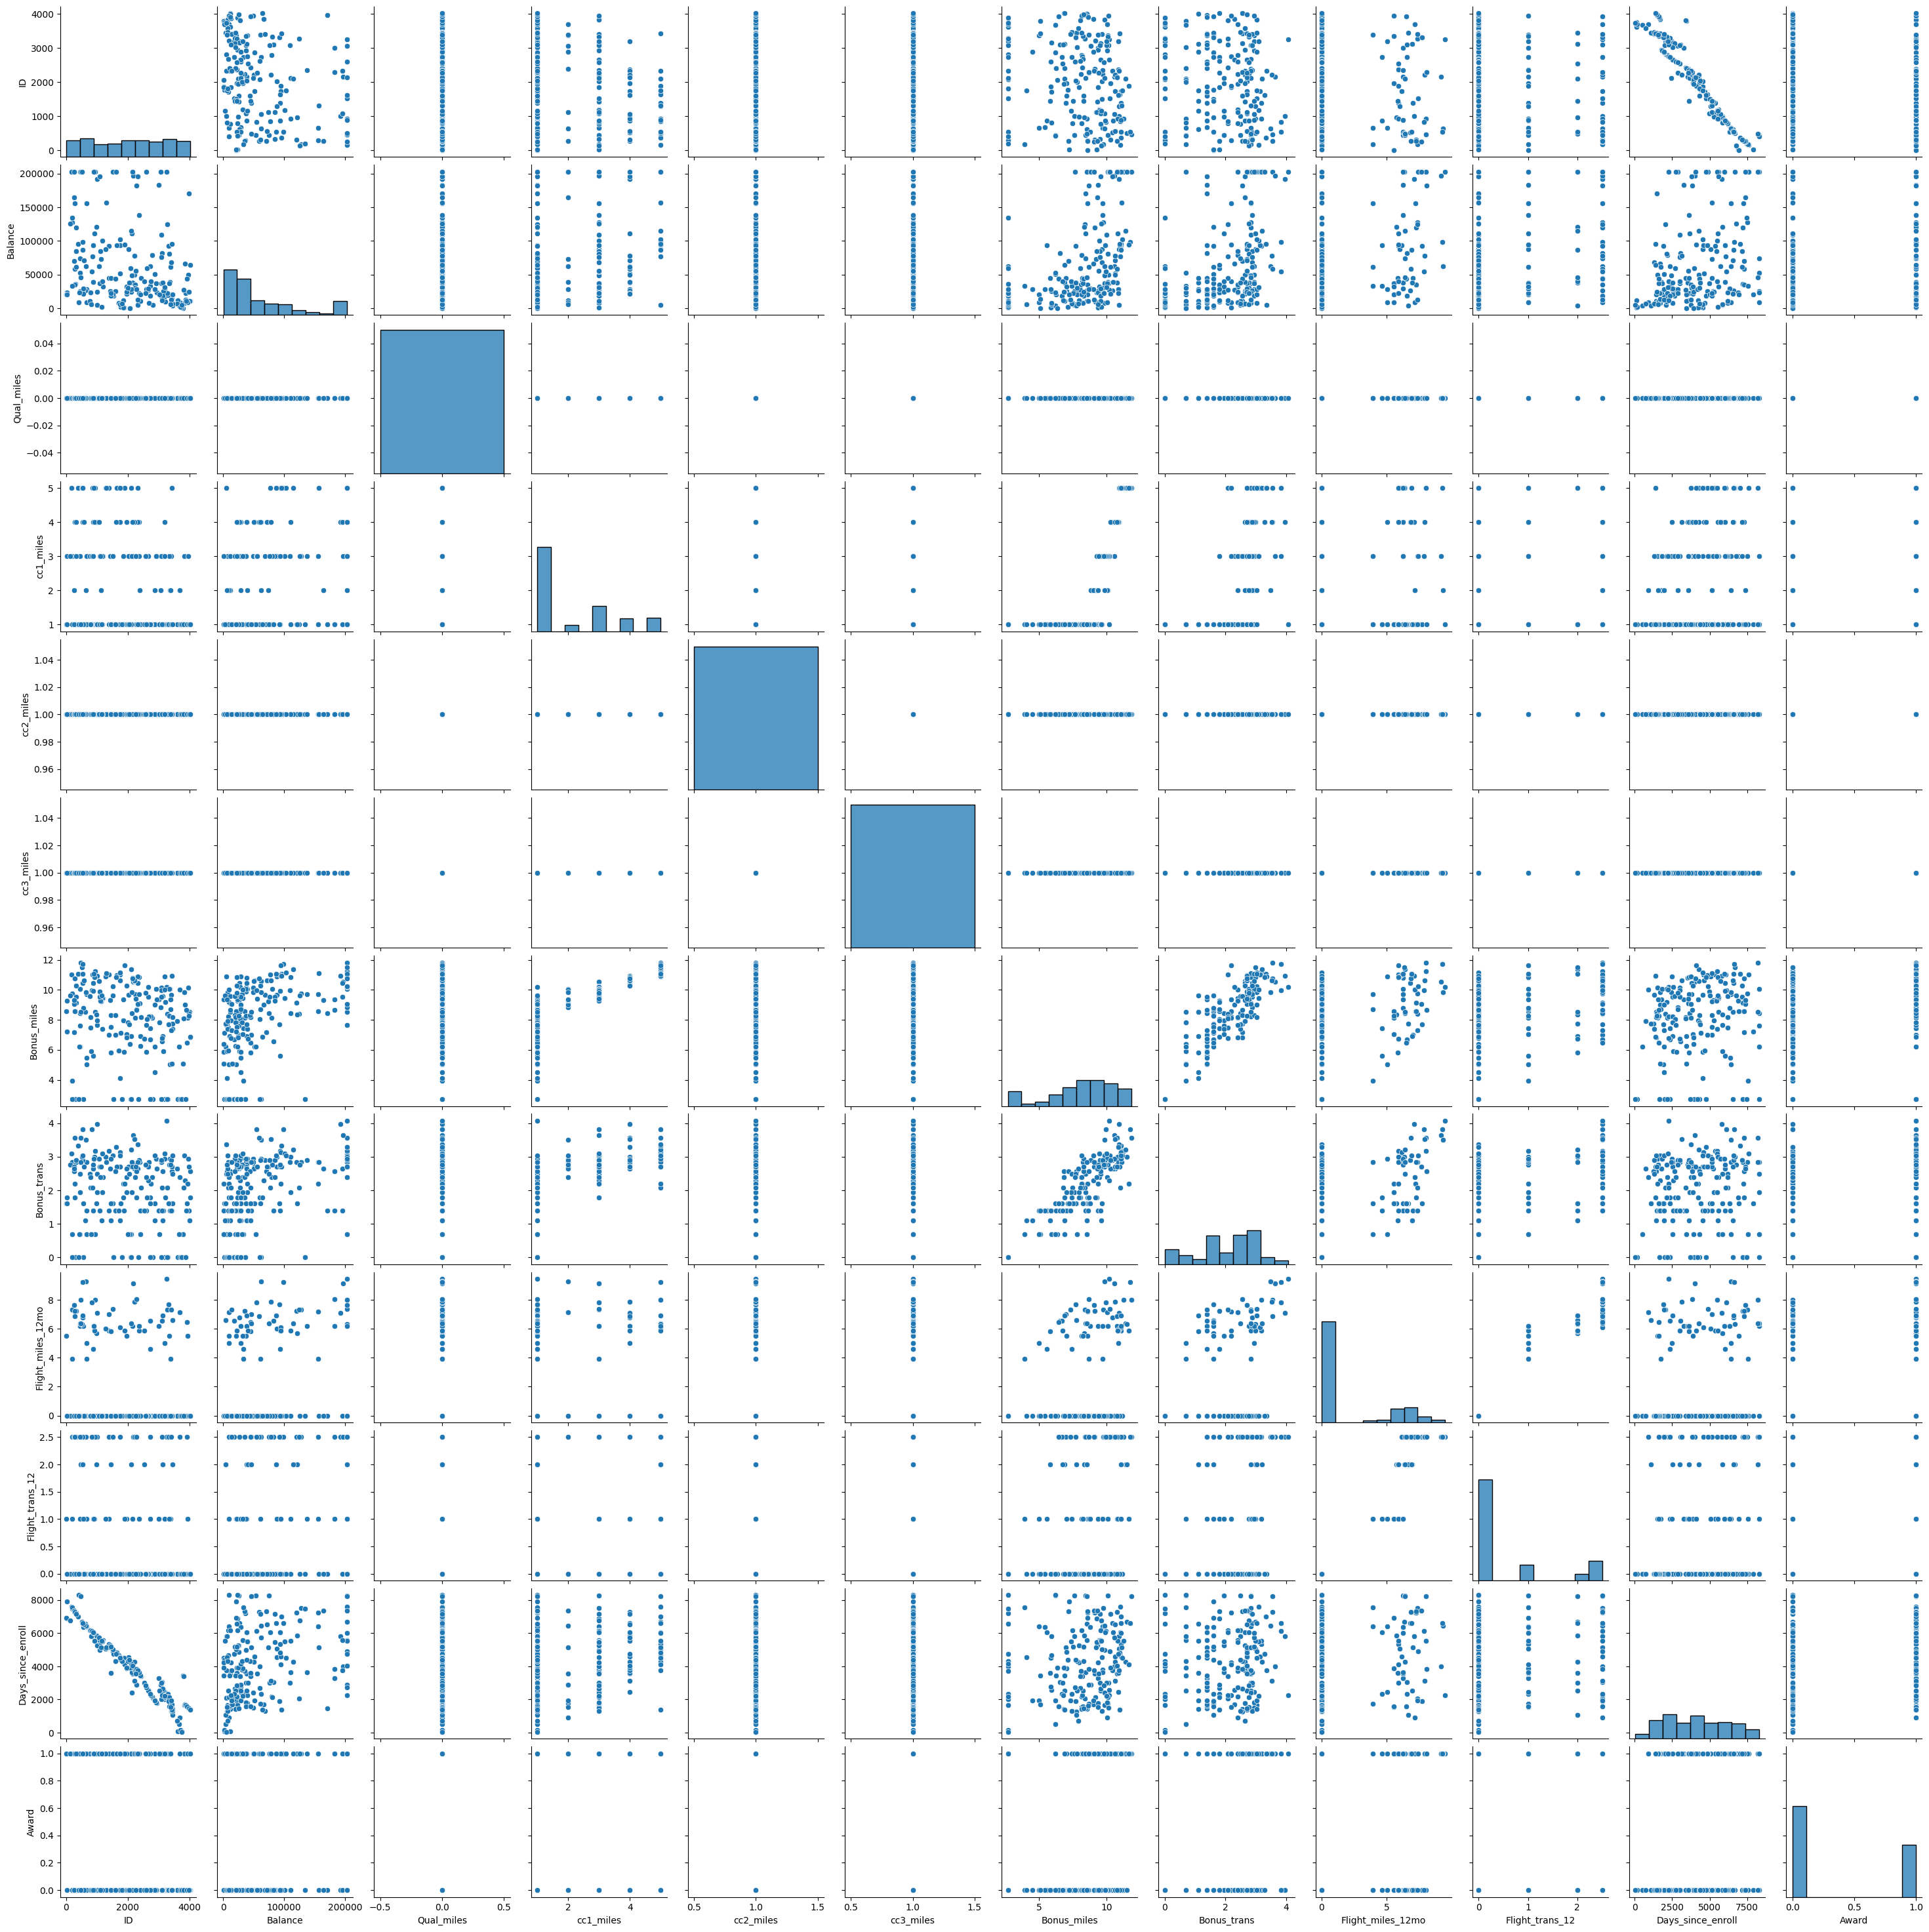

In [10]:
sns.pairplot(df.sample(200))
plt.show()

In [11]:
df = df.drop(columns=['Award?'], errors='ignore')

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, random_state=42)  # keep 90% variance
X_pca = pca.fit_transform(X)

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.27615667208427047
K=3, Score=0.30643277940427716
K=4, Score=0.282327553325548
K=5, Score=0.2815752823219287
K=6, Score=0.2757826510650376
K=7, Score=0.2785007848570905
K=8, Score=0.27921898042213067
K=9, Score=0.2732173055034625


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Select only original numerical columns
X = df[['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles',
        'cc3_miles', 'Bonus_miles', 'Bonus_trans',
        'Flight_miles_12mo', 'Flight_trans_12',
        'Days_since_enroll', 'Award']]

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Check silhouette score for different K
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.29115586489295026
K=3, Score=0.27172634161507647
K=4, Score=0.24455539721273453
K=5, Score=0.25475751733669183
K=6, Score=0.2710558306600758
K=7, Score=0.2779234087488256
K=8, Score=0.26091622783956114
K=9, Score=0.26225452561845847


In [14]:
from sklearn.preprocessing import StandardScaler

# Select only numerical columns
X = df.select_dtypes(include=['int64', 'float64'])

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [15]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1973
 2     749
 1     731
 3     544
-1       2
Name: count, dtype: int64


In [16]:
#DBSCAN Clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

In [17]:
from sklearn.cluster import DBSCAN

dbscan1 = DBSCAN(eps=0.5, min_samples=5)
labels1 = dbscan1.fit_predict(scaled_data)

dbscan2 = DBSCAN(eps=1.0, min_samples=5)
labels2 = dbscan2.fit_predict(scaled_data)

dbscan3 = DBSCAN(eps=1.5, min_samples=5)
labels3 = dbscan3.fit_predict(scaled_data)

print("eps=0.5:", set(labels1))
print("eps=1.0:", set(labels2))
print("eps=1.5:", set(labels3))

eps=0.5: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(-1)}
eps=1.0: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(-1)}
eps=1.5: {np.int64(0), np.int64(1), np.int64(2),

In [18]:
print("DBSCAN Silhouette Score:", silhouette_score(scaled_data, db_labels))

DBSCAN Silhouette Score: 0.19887471510479773


## Visualization

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df['KMeans_Cluster'] = kmeans_labels

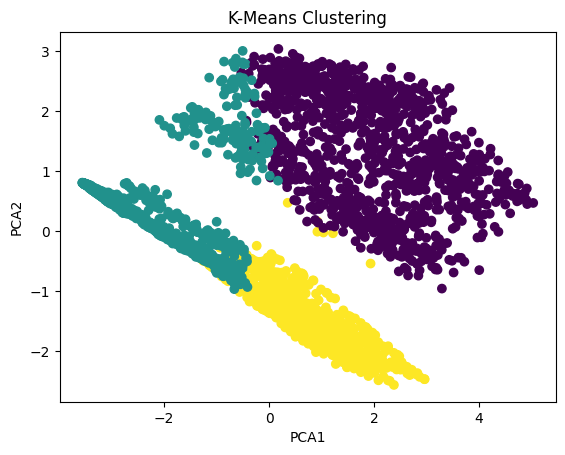

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

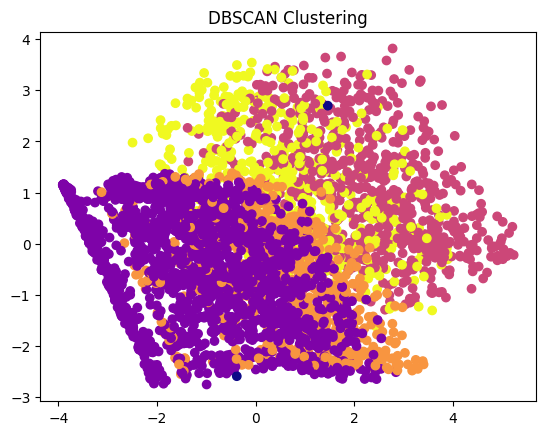

In [22]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.show()

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Apply K-Means with best K = 3
kmeans = KMeans(n_clusters=2, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

# Store labels in dataframe
df['KMeans_Cluster'] = kmeans_labels

# Calculate silhouette score
score = silhouette_score(scaled_data, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.29115586489295026


In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

In [33]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.3058488892318211


Clustering on PCA-transformed data may produce different Silhouette Scores because PCA reduces dimensionality and removes noise. This can improve or reduce cluster separation depending on the dataset structure.

Comparing both helps evaluate whether dimensionality reduction improves clustering performance.

In [24]:
print(df['KMeans_Cluster'].value_counts())

KMeans_Cluster
1    1491
2    1387
0    1121
Name: count, dtype: int64


In [25]:
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1973
 2     749
 1     731
 3     544
-1       2
Name: count, dtype: int64


In [26]:
df.groupby('KMeans_Cluster').mean()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,1762.193577,95669.697145,0.0,2.455843,1.0,1.0,9.541510,2.699003,6.742032,1.937110,4592.424621,0.635147,1.726137
1,2565.145540,27382.878102,0.0,1.023474,1.0,1.0,5.792102,1.144148,0.557437,0.126090,3111.121395,0.099262,0.445339
2,1627.405912,77099.619863,0.0,2.852920,1.0,1.0,9.722824,2.704760,0.017501,0.004326,4818.550108,0.447729,0.908435
